In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append(os.path.abspath("src"))

In [3]:
import pprint

import pandas as pd
from IPython.display import Image, display
from langchain_core.prompt_values import ChatPromptValue
from langchain_core.prompts import ChatPromptTemplate

from extractors.extractor import PllumExtractor
from polish_kg_langchain import ConfigSchema
from polish_kg_langchain.create_chat_huggingface import create_chat_huggingface
from src.polish_kg_langchain import PolishKGLangchainGraph

In [4]:
extractor = PllumExtractor(device="cuda")
llm = extractor.model
tokenizer = extractor.tokenizer

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
relations_schema = pd.read_csv("data/edc_baseline/schema.csv", header=None)

relations_description = ""
for i in range(0, len(relations_schema)):
    relation_name, relation_description = relations_schema.iloc[i]
    relations_description += f"{relation_name} - {relation_description}\n"

with open("data/edc_baseline/oie_few_shot_examples.txt", "r") as file:
    fewshot_examples = "".join(file.readlines())


def create_system_content(relations_description: str, fewshot_examples: str) -> str:
    return f"""Twoim zadaniem jest wyciągnąć jedną relację łączącą dwa obiekty występujące w tekście, jako trójkę. Trójka musi być w postaci [[Poprzednik, Relacja, Następnik]]. Poprzednik i Następnik są wyrażeniami zapisanymi w tekście. Relacja jest krótkim zapisem związku, jaki łączy Poprzednik i Następnik.
W swojej odpowiedzi przedstaw dokładnie jedną trójkę. Jeśli w tekście jest więcej możliwych trójek, wybierz najardziej prawdopodobną. Nie podawaj żadnych innych informacji czy wyjaśnień.
            
Jedyne relacje, jakie możesz wyciągnąć, to:
{relations_description}

Poniżej przykłady zdań, w których występują obiekty, dla których należy wyciągnąć trójkę:
{fewshot_examples}"""


def create_prompt_content(sample: str) -> str:
    return f"""Tekst: {sample}
Trójka:"""

In [6]:
graph2 = PolishKGLangchainGraph()

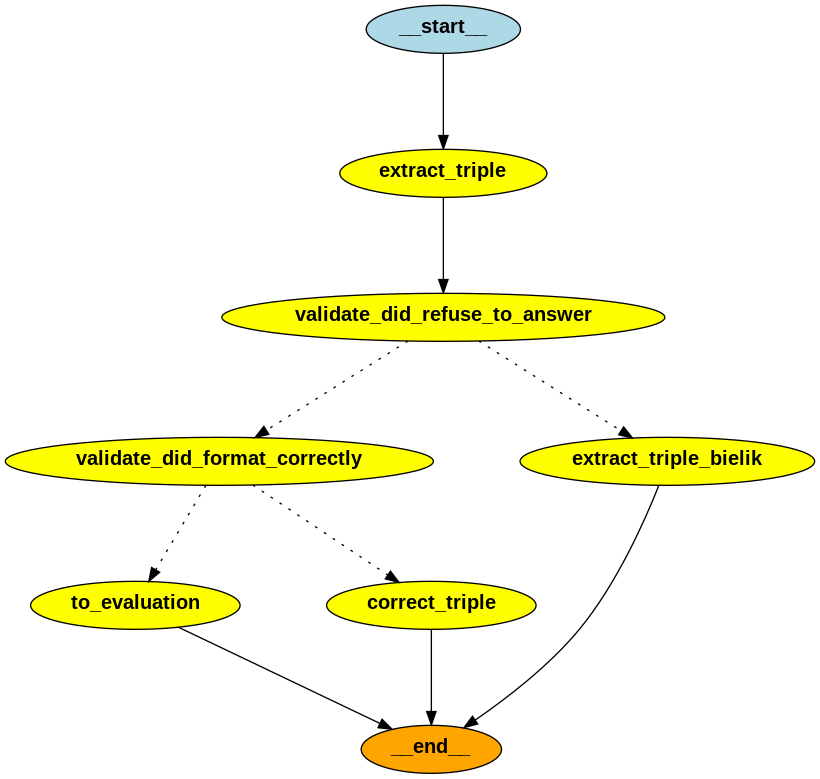

In [7]:
display(Image(graph2.graph.get_graph().draw_png()))

In [8]:
chat_huggingface = create_chat_huggingface(llm=llm, tokenizer=tokenizer)

In [9]:
from langchain_core.runnables.config import RunnableConfig

template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            create_system_content(relations_description, fewshot_examples),
        ),
        ("human", "{text}"),
    ]
)

prompt: ChatPromptValue = template.invoke(
    {"text": create_prompt_content("Wojciech Szczęsny jest bramkarzem Juventusu")}
)  # type:ignore

config: ConfigSchema = {"base_llm": chat_huggingface}
invocation_config: RunnableConfig = {
    "configurable": dict(config),
}

data = graph2.graph.invoke(
    {
        "messages": prompt.messages,
    },
    config=invocation_config,
)
print("\nmessages")
pprint.pprint(data["messages"])

print("\nDid attempt to answer?")
pprint.pprint(data["did_attempt_to_answer"])
print("\nAttempt checker messages")
pprint.pprint(data["attempt_checker_messages"])


if "has_correct_format" in data:
    print("\nIs format correct?")
    pprint.pprint(data["has_correct_format"])
    print("\nFormat checker messages")
    pprint.pprint(data["format_checker_messages"])

Extract triple bielik:  {'messages': [SystemMessage(content="Twoim zadaniem jest wyciągnąć jedną relację łączącą dwa obiekty występujące w tekście, jako trójkę. Trójka musi być w postaci [[Poprzednik, Relacja, Następnik]]. Poprzednik i Następnik są wyrażeniami zapisanymi w tekście. Relacja jest krótkim zapisem związku, jaki łączy Poprzednik i Następnik.\nW swojej odpowiedzi przedstaw dokładnie jedną trójkę. Jeśli w tekście jest więcej możliwych trójek, wybierz najardziej prawdopodobną. Nie podawaj żadnych innych informacji czy wyjaśnień.\n            \nJedyne relacje, jakie możesz wyciągnąć, to:\nzawód - Poprzednik wykonuje pracę w zawodzie określonym przez następnik.\nczłonek - Poprzednik jest członkiem organizacji określonej przez następnik.\nmiejsce urodzenia - Poprzednik urodził się w miejscu określonym przez następnik.\nlokalizacja - Poprzednik znajduje się w miejscu określonym przez następnik.\ntyp - Poprzednik jest rodzaju określonego przez następnik.\nsiedziba - Siedziba poprze